## Phase 1 — Dataset Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_PATH = "../data/razorattacklab_transactions.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20000, 24)


In [3]:
df.head()

,transaction_id,user_id,merchant_id,device_id,ip_id,amount_inr,timestamp_utc,location,payment_method,merchant_category,account_age_days,failed_attempts_24h,transactions_1h,transactions_24h,unique_users_on_device,unique_accounts_on_ip,is_new_device,is_new_location,average_amount_inr,amount_to_average_ratio,is_fraud,fraud_type,risk_score,recommended_decision
0,TXN0000001,U00575,M0173,D02225,IP03001,345.62,2026-01-01T10:27:00+00:00,Kolkata,UPI,subscriptions,396,5,1,6,2,2,0,0,967.67,0.357,0,none,6.63,ALLOW
1,TXN0000002,U04711,M0279,D05691,IP00357,13730.66,2026-01-27T04:00:00+00:00,Jaipur,Netbanking,food,909,0,8,15,1,1,0,0,1526.67,1.781,1,refund_abuse,97.43,BLOCK
2,TXN0000003,U00038,M0198,D02340,IP06516,1378.22,2026-02-24T20:44:00+00:00,Ahmedabad,Wallet,utilities,948,5,5,5,2,1,0,0,971.21,1.419,0,none,13.43,ALLOW
3,TXN0000004,U01997,M0191,D05995,IP05428,1718.64,2026-02-08T11:40:00+00:00,Jaipur,Netbanking,utilities,908,0,5,12,1,1,0,0,1512.60,1.136,0,none,7.07,ALLOW
4,TXN0000005,U03397,M0129,D06141,IP06851,584.50,2026-02-23T03:42:00+00:00,Kolkata,UPI,education,60,0,1,14,4,1,0,0,1152.14,0.507,0,none,1.93,ALLOW


In [4]:
df.tail()

,transaction_id,user_id,merchant_id,device_id,ip_id,amount_inr,timestamp_utc,location,payment_method,merchant_category,account_age_days,failed_attempts_24h,transactions_1h,transactions_24h,unique_users_on_device,unique_accounts_on_ip,is_new_device,is_new_location,average_amount_inr,amount_to_average_ratio,is_fraud,fraud_type,risk_score,recommended_decision
19995,TXN0019996,U01256,M0244,D01673,IP05044,1280.38,2026-02-18T13:42:00+00:00,Lucknow,Wallet,gaming,565,2,1,17,1,3,0,1,820.21,1.561,0,none,8.64,ALLOW
19996,TXN0019997,U02798,M0080,D05143,IP02131,3479.72,2026-01-19T11:42:00+00:00,Lucknow,UPI,education,214,0,1,18,4,1,0,0,2310.20,1.506,0,none,6.30,ALLOW
19997,TXN0019998,U02999,M0065,D01708,IP04361,352.33,2026-02-03T06:11:00+00:00,Lucknow,Wallet,ecommerce,109,0,1,4,1,3,0,0,530.24,0.664,0,none,2.25,ALLOW
19998,TXN0019999,U01256,M0102,D03448,IP04716,681.34,2026-01-20T12:03:00+00:00,Jaipur,Wallet,education,827,4,3,5,1,2,0,0,780.38,0.873,0,none,9.83,ALLOW
19999,TXN0020000,U00078,M0051,D03487,IP06984,813.29,2026-01-17T20:38:00+00:00,Ahmedabad,Card,food,717,4,1,20,1,4,0,1,397.54,2.046,0,none,25.10,ALLOW


In [5]:
print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns:
1. transaction_id
2. user_id
3. merchant_id
4. device_id
5. ip_id
6. amount_inr
7. timestamp_utc
8. location
9. payment_method
10. merchant_category
11. account_age_days
12. failed_attempts_24h
13. transactions_1h
14. transactions_24h
15. unique_users_on_device
16. unique_accounts_on_ip
17. is_new_device
18. is_new_location
19. average_amount_inr
20. amount_to_average_ratio
21. is_fraud
22. fraud_type
23. risk_score
24. recommended_decision


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           20000 non-null  object 
 1   user_id                  20000 non-null  object 
 2   merchant_id              20000 non-null  object 
 3   device_id                20000 non-null  object 
 4   ip_id                    20000 non-null  object 
 5   amount_inr               20000 non-null  float64
 6   timestamp_utc            20000 non-null  object 
 7   location                 20000 non-null  object 
 8   payment_method           20000 non-null  object 
 9   merchant_category        20000 non-null  object 
 10  account_age_days         20000 non-null  int64  
 11  failed_attempts_24h      20000 non-null  int64  
 12  transactions_1h          20000 non-null  int64  
 13  transactions_24h         20000 non-null  int64  
 14  unique_users_on_device

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": missing_percentage
})

missing_report.sort_values(
    by="missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
transaction_id,0,0.0
user_id,0,0.0
merchant_id,0,0.0
device_id,0,0.0
ip_id,0,0.0
amount_inr,0,0.0
timestamp_utc,0,0.0
location,0,0.0
payment_method,0,0.0
merchant_category,0,0.0


In [9]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [10]:
print(df["is_fraud"].value_counts())

is_fraud
0    18447
1     1553
Name: count, dtype: int64


In [11]:
fraud_percentage = df["is_fraud"].value_counts(normalize=True) * 100

print(fraud_percentage)

is_fraud
0    92.235
1     7.765
Name: proportion, dtype: float64


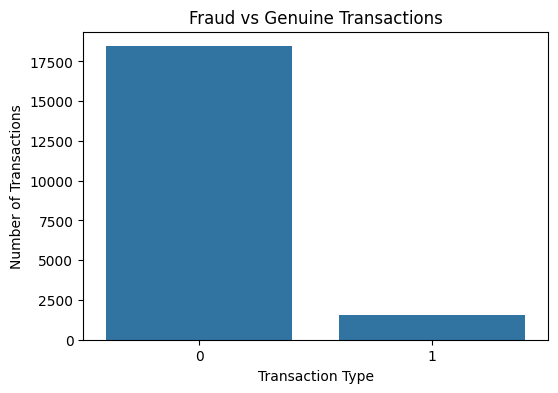

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="is_fraud")

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

In [14]:
print(df["fraud_type"].value_counts())

fraud_type
none                      18447
emerging_anomaly            376
rapid_transactions          262
card_testing                259
account_takeover            229
refund_abuse                217
coordinated_fraud_ring      210
Name: count, dtype: int64


In [16]:
print(
    df["fraud_type"].value_counts(normalize=True) * 100
)

fraud_type
none                      92.235
emerging_anomaly           1.880
rapid_transactions         1.310
card_testing               1.295
account_takeover           1.145
refund_abuse               1.085
coordinated_fraud_ring     1.050
Name: proportion, dtype: float64


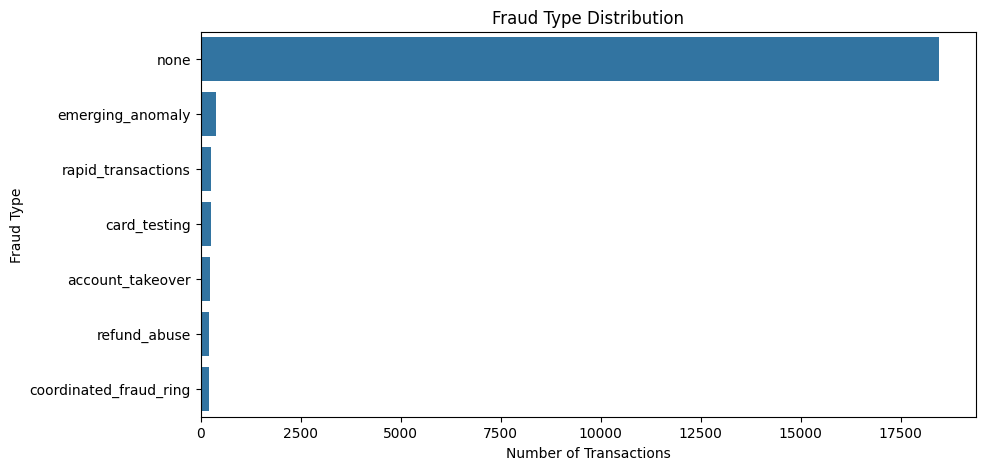

In [17]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="fraud_type",
    order=df["fraud_type"].value_counts().index
)

plt.title("Fraud Type Distribution")
plt.xlabel("Number of Transactions")
plt.ylabel("Fraud Type")

plt.show()

In [18]:
fraud_attack = pd.crosstab(
    df["fraud_type"],
    df["is_fraud"]
)

fraud_attack

is_fraud,0,1
fraud_type,,
account_takeover,0,229
card_testing,0,259
coordinated_fraud_ring,0,210
emerging_anomaly,0,376
none,18447,0
rapid_transactions,0,262
refund_abuse,0,217


In [20]:
df["amount_inr"].describe()

count    20000.000000
mean      2304.933465
std       6528.249554
min         13.230000
25%        498.392500
50%        946.210000
75%       1863.005000
max      89777.680000
Name: amount_inr, dtype: float64

In [21]:
df.groupby("is_fraud")["amount_inr"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,18447.0,1356.360742,1491.531578,28.64,495.49,906.94,1685.86,38875.01
1,1553.0,13572.364900,19621.457376,13.23,767.26,5839.26,17199.90,89777.68


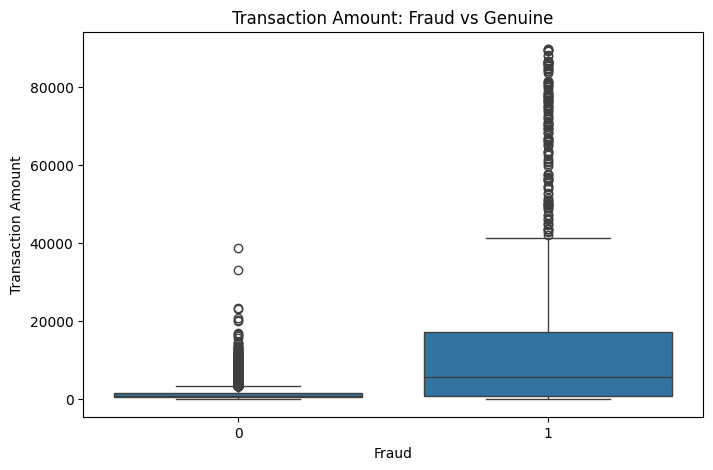

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount_inr"
)

plt.title("Transaction Amount: Fraud vs Genuine")
plt.xlabel("Fraud")
plt.ylabel("Transaction Amount")

plt.show()

In [25]:
entity_columns = [
    "user_id",
    "merchant_id",
    "device_id",
    "ip_id"
]

for column in entity_columns:
    if column in df.columns:
        print(
            f"{column}: {df[column].nunique()} unique values"
        )

user_id: 4949 unique values
merchant_id: 300 unique values
device_id: 6199 unique values
ip_id: 8053 unique values


In [26]:
device_user_counts = (
    df.groupby("device_id")["user_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(device_user_counts.head(20))

device_id
D_RING_07    27
D_RING_05    23
D_RING_02    21
D_RING_01    19
D_RING_06    17
D_RING_03    17
D_RING_08    16
D_RING_04    16
D03168       10
D03003       10
D03320       10
D06202       10
D03302       10
D03470        9
D03065        9
D04430        9
D03014        9
D06161        9
D05408        9
D05451        9
Name: user_id, dtype: int64


In [27]:
suspicious_devices = device_user_counts[
    device_user_counts >= 3
]

print(
    "Devices used by 3+ users:",
    len(suspicious_devices)
)

Devices used by 3+ users: 3835


In [29]:
ip_user_counts = (
    df.groupby("ip_id")["user_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(ip_user_counts.head(20))

ip_id
IP_RING_02    31
IP_RING_04    27
IP_RING_01    26
IP_RING_03    23
IP_RING_05    22
IP08151       10
IP03486       10
IP04907        9
IP04443        9
IP00826        9
IP05460        9
IP08468        9
IP06452        9
IP00385        9
IP08197        8
IP02788        8
IP03857        8
IP07705        8
IP04070        8
IP00189        8
Name: user_id, dtype: int64


In [30]:
suspicious_ips = ip_user_counts[
    ip_user_counts >= 5
]

print(
    "IPs used by 5+ users:",
    len(suspicious_ips)
)

IPs used by 5+ users: 631


In [31]:
print("=" * 50)
print("RAZOR ATTACK LAB - DATA VALIDATION REPORT")
print("=" * 50)

print(f"Total transactions : {len(df):,}")
print(f"Total columns      : {df.shape[1]:,}")
print(f"Duplicate rows     : {df.duplicated().sum():,}")
print(f"Missing values     : {df.isnull().sum().sum():,}")

if "is_fraud" in df.columns:
    fraud_count = df["is_fraud"].sum()
    genuine_count = len(df) - fraud_count

    print(f"Genuine transactions: {genuine_count:,}")
    print(f"Fraud transactions   : {fraud_count:,}")
    print(f"Fraud rate           : {(fraud_count / len(df)) * 100:.2f}%")

if "user_id" in df.columns:
    print(f"Unique users        : {df['user_id'].nunique():,}")

if "device_id" in df.columns:
    print(f"Unique devices      : {df['device_id'].nunique():,}")

if "ip_address" in df.columns:
    print(f"Unique IPs          : {df['ip_address'].nunique():,}")

if "card_id" in df.columns:
    print(f"Unique cards        : {df['card_id'].nunique():,}")

print("=" * 50)

RAZOR ATTACK LAB - DATA VALIDATION REPORT
Total transactions : 20,000
Total columns      : 24
Duplicate rows     : 0
Missing values     : 0
Genuine transactions: 18,447
Fraud transactions   : 1,553
Fraud rate           : 7.76%
Unique users        : 4,949
Unique devices      : 6,199


## Phase 2 — Feature Engineering

In [32]:
df["timestamp_utc"] = pd.to_datetime(
    df["timestamp_utc"],
    errors="coerce"
)

print(df["timestamp_utc"].dtype)

datetime64[ns, UTC]


In [33]:
df["transaction_hour"] = df["timestamp_utc"].dt.hour

df["day_of_week"] = df["timestamp_utc"].dt.dayofweek

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

In [34]:
df[
    [
        "timestamp_utc",
        "transaction_hour",
        "day_of_week",
        "is_weekend"
    ]
].head()

,timestamp_utc,transaction_hour,day_of_week,is_weekend
0,2026-01-01 10:27:00+00:00,10,3,0
1,2026-01-27 04:00:00+00:00,4,1,0
2,2026-02-24 20:44:00+00:00,20,1,0
3,2026-02-08 11:40:00+00:00,11,6,1
4,2026-02-23 03:42:00+00:00,3,0,0


In [35]:
df["is_night"] = (
    (df["transaction_hour"] < 6) |
    (df["transaction_hour"] >= 23)
).astype(int)

In [36]:
df[
    [
        "transaction_hour",
        "is_night"
    ]
].head()

,transaction_hour,is_night
0,10,0
1,4,1
2,20,0
3,11,0
4,3,1


In [37]:
df["high_amount_deviation"] = (
    df["amount_to_average_ratio"] >= 3
).astype(int)

In [38]:
df["high_velocity"] = (
    (df["transactions_1h"] >= 5) |
    (df["transactions_24h"] >= 20)
).astype(int)

In [39]:
df["shared_infrastructure"] = (
    (df["unique_users_on_device"] >= 3) |
    (df["unique_accounts_on_ip"] >= 5)
).astype(int)

In [40]:
df["new_account_new_device"] = (
    (df["account_age_days"] <= 7) &
    (df["is_new_device"] == 1)
).astype(int)

In [41]:
new_features = [
    "transaction_hour",
    "day_of_week",
    "is_weekend",
    "is_night",
    "high_amount_deviation",
    "high_velocity",
    "shared_infrastructure",
    "new_account_new_device"
]

df[new_features].head()

,transaction_hour,day_of_week,is_weekend,is_night,high_amount_deviation,high_velocity,shared_infrastructure,new_account_new_device
0,10,3,0,0,0,0,0,0
1,4,1,0,1,0,1,0,0
2,20,1,0,0,0,1,0,0
3,11,6,1,0,0,1,0,0
4,3,0,0,1,0,0,1,0


In [42]:
print("New shape:", df.shape)

New shape: (20000, 32)


In [43]:
target = "is_fraud"

drop_columns = [
    "transaction_id",
    "risk_score",
    "recommended_decision",
    "fraud_type",
    "is_fraud",
    "timestamp_utc"
]

X = df.drop(columns=drop_columns)

y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 26)
y shape: (20000,)


In [44]:
X.head()

,user_id,merchant_id,device_id,ip_id,amount_inr,location,payment_method,merchant_category,account_age_days,failed_attempts_24h,transactions_1h,transactions_24h,unique_users_on_device,unique_accounts_on_ip,is_new_device,is_new_location,average_amount_inr,amount_to_average_ratio,transaction_hour,day_of_week,is_weekend,is_night,high_amount_deviation,high_velocity,shared_infrastructure,new_account_new_device
0,U00575,M0173,D02225,IP03001,345.62,Kolkata,UPI,subscriptions,396,5,1,6,2,2,0,0,967.67,0.357,10,3,0,0,0,0,0,0
1,U04711,M0279,D05691,IP00357,13730.66,Jaipur,Netbanking,food,909,0,8,15,1,1,0,0,1526.67,1.781,4,1,0,1,0,1,0,0
2,U00038,M0198,D02340,IP06516,1378.22,Ahmedabad,Wallet,utilities,948,5,5,5,2,1,0,0,971.21,1.419,20,1,0,0,0,1,0,0
3,U01997,M0191,D05995,IP05428,1718.64,Jaipur,Netbanking,utilities,908,0,5,12,1,1,0,0,1512.60,1.136,11,6,1,0,0,1,0,0
4,U03397,M0129,D06141,IP06851,584.50,Kolkata,UPI,education,60,0,1,14,4,1,0,0,1152.14,0.507,3,0,0,1,0,0,1,0


In [45]:
print("New shape:", df.shape)
print(X.dtypes)

New shape: (20000, 32)
user_id                     object
merchant_id                 object
device_id                   object
ip_id                       object
amount_inr                 float64
location                    object
payment_method              object
merchant_category           object
account_age_days             int64
failed_attempts_24h          int64
transactions_1h              int64
transactions_24h             int64
unique_users_on_device       int64
unique_accounts_on_ip        int64
is_new_device                int64
is_new_location              int64
average_amount_inr         float64
amount_to_average_ratio    float64
transaction_hour             int32
day_of_week                  int32
is_weekend                   int64
is_night                     int64
high_amount_deviation        int64
high_velocity                int64
shared_infrastructure        int64
new_account_new_device       int64
dtype: object


## Phase 3 — Categorical Encoding + Train/Test Split

In [46]:
id_columns = [
    "user_id",
    "merchant_id",
    "device_id",
    "ip_id"
]

X_model = X.drop(columns=id_columns)

print("Shape after removing IDs:", X_model.shape)

Shape after removing IDs: (20000, 22)


In [47]:
categorical_columns = [
    "location",
    "payment_method",
    "merchant_category"
]

numeric_columns = [
    column
    for column in X_model.columns
    if column not in categorical_columns
]

print("Categorical columns:")
print(categorical_columns)

print("\nNumeric columns:")
print(numeric_columns)

Categorical columns:
['location', 'payment_method', 'merchant_category']

Numeric columns:
['amount_inr', 'account_age_days', 'failed_attempts_24h', 'transactions_1h', 'transactions_24h', 'unique_users_on_device', 'unique_accounts_on_ip', 'is_new_device', 'is_new_location', 'average_amount_inr', 'amount_to_average_ratio', 'transaction_hour', 'day_of_week', 'is_weekend', 'is_night', 'high_amount_deviation', 'high_velocity', 'shared_infrastructure', 'new_account_new_device']


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (16000, 22)
Testing data : (4000, 22)

Training target distribution:
is_fraud
0    14758
1     1242
Name: count, dtype: int64

Testing target distribution:
is_fraud
0    3689
1     311
Name: count, dtype: int64


In [50]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [51]:
X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

In [52]:
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape :", X_test_encoded.shape)

Encoded training shape: (16000, 40)
Encoded testing shape : (4000, 40)


In [53]:
feature_names = preprocessor.get_feature_names_out()

print("Total features:", len(feature_names))

for feature in feature_names:
    print(feature)

Total features: 40
categorical__location_Ahmedabad
categorical__location_Bengaluru
categorical__location_Chennai
categorical__location_Delhi
categorical__location_Hyderabad
categorical__location_Jaipur
categorical__location_Kolkata
categorical__location_Lucknow
categorical__location_Mumbai
categorical__location_Pune
categorical__payment_method_Card
categorical__payment_method_Netbanking
categorical__payment_method_UPI
categorical__payment_method_Wallet
categorical__merchant_category_ecommerce
categorical__merchant_category_education
categorical__merchant_category_food
categorical__merchant_category_gaming
categorical__merchant_category_subscriptions
categorical__merchant_category_travel
categorical__merchant_category_utilities
remainder__amount_inr
remainder__account_age_days
remainder__failed_attempts_24h
remainder__transactions_1h
remainder__transactions_24h
remainder__unique_users_on_device
remainder__unique_accounts_on_ip
remainder__is_new_device
remainder__is_new_location
remainde

## Phase 3 — XGBoost Fraud Detection

In [54]:
from xgboost import XGBClassifier

In [55]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 11.882447665056361


In [56]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

In [57]:
model.fit(
    X_train_encoded,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [58]:
y_prob = model.predict_proba(X_test_encoded)[:, 1]

print(y_prob[:10])

[0.00857728 0.04375942 0.24411805 0.00953066 0.04996956 0.03139076
 0.03248468 0.04540979 0.07149442 0.01244763]


In [59]:
y_pred = (y_prob >= 0.5).astype(int)

In [60]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [61]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Genuine", "Fraud"]
    )
)

              precision    recall  f1-score   support

     Genuine       0.98      0.99      0.99      3689
       Fraud       0.92      0.75      0.83       311

    accuracy                           0.98      4000
   macro avg       0.95      0.87      0.91      4000
weighted avg       0.98      0.98      0.97      4000



In [62]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3670   19]
 [  77  234]]


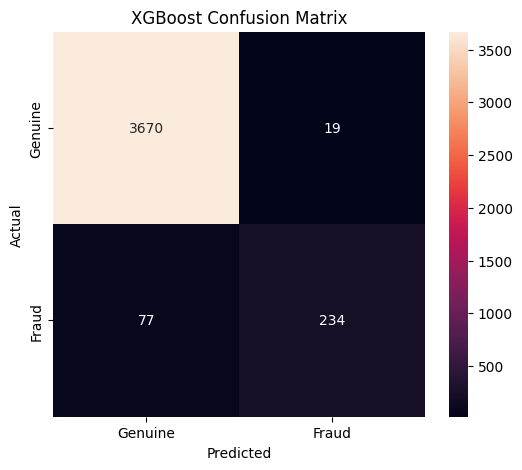

In [63]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Genuine", "Fraud"],
    yticklabels=["Genuine", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [64]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9245423301568318


In [65]:
pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.8378604310839943


In [66]:
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

ROC-AUC : 0.9245
PR-AUC  : 0.8379


In [67]:
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(15)

,feature,importance
24,remainder__transactions_1h,0.105398
21,remainder__amount_inr,0.087171
28,remainder__is_new_device,0.058877
23,remainder__failed_attempts_24h,0.036906
25,remainder__transactions_24h,0.035011
26,remainder__unique_users_on_device,0.030879
36,remainder__high_amount_deviation,0.030850
29,remainder__is_new_location,0.030633
37,remainder__high_velocity,0.027261
19,categorical__merchant_category_travel,0.024138


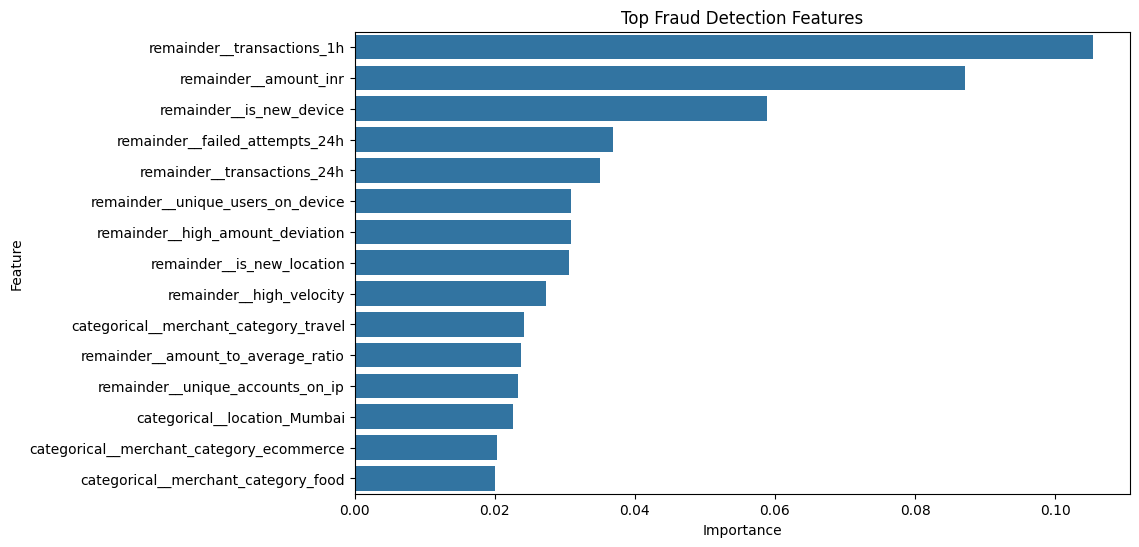

In [68]:
plt.figure(figsize=(10, 6))

top_features = importance.head(15)

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top Fraud Detection Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [69]:
result = X_test.copy()

result["actual_fraud"] = y_test.values
result["fraud_probability"] = y_prob
result["predicted_fraud"] = y_pred

result.head(20)

,amount_inr,location,payment_method,merchant_category,account_age_days,failed_attempts_24h,transactions_1h,transactions_24h,unique_users_on_device,unique_accounts_on_ip,is_new_device,is_new_location,average_amount_inr,amount_to_average_ratio,transaction_hour,day_of_week,is_weekend,is_night,high_amount_deviation,high_velocity,shared_infrastructure,new_account_new_device,actual_fraud,fraud_probability,predicted_fraud
1748,443.22,Ahmedabad,UPI,subscriptions,469,0,1,3,1,2,0,1,357.17,1.241,12,6,1,0,0,0,0,0,0,0.008577,0
14496,848.18,Hyderabad,Netbanking,utilities,975,0,2,14,1,1,1,0,519.59,1.632,22,1,0,0,0,0,0,0,0,0.043759,0
19226,4760.50,Kolkata,Wallet,subscriptions,1428,0,5,24,5,1,0,0,587.84,8.098,2,2,0,1,1,1,1,0,0,0.244118,0
4543,545.60,Pune,Card,utilities,404,0,2,3,2,5,0,0,414.99,1.315,9,4,0,0,0,0,1,0,0,0.009531,0
19536,1012.46,Mumbai,Netbanking,utilities,642,0,2,10,3,1,0,0,415.96,2.434,2,4,0,1,0,0,1,0,0,0.049970,0
10841,222.34,Lucknow,Wallet,subscriptions,535,0,1,14,1,1,0,0,780.20,0.285,5,1,0,1,0,0,0,0,0,0.031391,0
3923,559.10,Hyderabad,Wallet,utilities,1420,0,1,14,2,2,0,0,490.72,1.139,20,3,0,0,0,0,0,0,0,0.032485,0
3663,712.32,Chennai,UPI,subscriptions,913,1,1,2,2,1,0,0,699.81,1.018,16,1,0,0,0,0,0,0,0,0.045410,0
9275,1780.53,Jaipur,Wallet,gaming,623,0,12,23,2,1,0,0,646.36,2.755,0,5,1,1,0,1,0,0,0,0.071494,0
4893,738.26,Delhi,UPI,gaming,42,0,12,12,1,4,0,0,621.98,1.187,2,1,0,1,0,1,0,0,0,0.012448,0


In [70]:
result["ml_risk_score"] = (
    result["fraud_probability"] * 100
).round(2)

In [71]:
test_results = df.loc[X_test.index, [
    "transaction_id",
    "user_id",
    "merchant_id",
    "device_id",
    "ip_id",
    "amount_inr",
    "fraud_type",
    "is_fraud"
]].copy()

test_results["fraud_probability"] = y_prob
test_results["predicted_fraud"] = y_pred

test_results["ml_risk_score"] = (
    test_results["fraud_probability"] * 100
).round(2)

test_results.head()

,transaction_id,user_id,merchant_id,device_id,ip_id,amount_inr,fraud_type,is_fraud,fraud_probability,predicted_fraud,ml_risk_score
1748,TXN0001749,U00319,M0062,D02707,IP04592,443.22,none,0,0.008577,0,0.86
14496,TXN0014497,U02349,M0231,D03470,IP04341,848.18,none,0,0.043759,0,4.38
19226,TXN0019227,U01564,M0280,D01957,IP08685,4760.50,none,0,0.244118,0,24.41
4543,TXN0004544,U00892,M0123,D03863,IP06405,545.60,none,0,0.009531,0,0.95
19536,TXN0019537,U03025,M0050,D03780,IP04211,1012.46,none,0,0.049970,0,5.00


In [72]:
missed_fraud = test_results[
    (test_results["is_fraud"] == 1) &
    (test_results["predicted_fraud"] == 0)
]

print("Missed fraud transactions:", len(missed_fraud))

missed_fraud.head(20)

Missed fraud transactions: 77


,transaction_id,user_id,merchant_id,device_id,ip_id,amount_inr,fraud_type,is_fraud,fraud_probability,predicted_fraud,ml_risk_score
9976,TXN0009977,U01351,M0008,D05205,IP05834,3332.05,emerging_anomaly,1,0.256352,0,25.639999
1785,TXN0001786,U04883,M0066,D05341,IP03397,202.95,emerging_anomaly,1,0.061772,0,6.180000
17013,TXN0017014,U04149,M0004,D04509,IP07636,941.89,emerging_anomaly,1,0.021461,0,2.150000
17700,TXN0017701,U02675,M0160,D02553,IP00285,256.89,emerging_anomaly,1,0.005220,0,0.520000
2032,TXN0002033,U04028,M0073,D05376,IP01750,2273.45,emerging_anomaly,1,0.053707,0,5.370000
3463,TXN0003464,U01040,M0122,D03835,IP05829,1075.19,emerging_anomaly,1,0.069730,0,6.970000
15311,TXN0015312,U01160,M0197,D01134,IP07506,420.17,emerging_anomaly,1,0.074665,0,7.470000
14492,TXN0014493,U04434,M0294,D06013,IP08483,1908.51,emerging_anomaly,1,0.465781,0,46.580002
17840,TXN0017841,U01757,M0182,D04453,IP06519,1683.98,emerging_anomaly,1,0.058901,0,5.890000
14232,TXN0014233,U02664,M0209,D00808,IP02256,795.45,emerging_anomaly,1,0.055735,0,5.570000


In [73]:
missed_fraud["fraud_type"].value_counts()

fraud_type
emerging_anomaly    65
refund_abuse        12
Name: count, dtype: int64

In [74]:
fraud_only = test_results[
    test_results["is_fraud"] == 1
]

attack_performance = (
    fraud_only
    .groupby("fraud_type")
    .agg(
        total_fraud=("is_fraud", "count"),
        detected=("predicted_fraud", "sum")
    )
)

attack_performance["detection_rate"] = (
    attack_performance["detected"] /
    attack_performance["total_fraud"]
)

attack_performance.sort_values(
    "detection_rate"
)

,total_fraud,detected,detection_rate
fraud_type,,,
emerging_anomaly,66,1,0.015152
refund_abuse,47,35,0.744681
card_testing,50,50,1.000000
account_takeover,47,47,1.000000
coordinated_fraud_ring,48,48,1.000000
rapid_transactions,53,53,1.000000


## Phase 4 — Isolation Forest

In [75]:
from sklearn.ensemble import IsolationForest

In [76]:
anomaly_features = [
    "amount_inr",
    "account_age_days",
    "failed_attempts_24h",
    "transactions_1h",
    "transactions_24h",
    "unique_users_on_device",
    "unique_accounts_on_ip",
    "is_new_device",
    "is_new_location",
    "average_amount_inr",
    "amount_to_average_ratio",
    "transaction_hour",
    "is_weekend",
    "is_night",
    "high_amount_deviation",
    "high_velocity",
    "shared_infrastructure",
    "new_account_new_device"
]

In [77]:
print(len(anomaly_features))

18


In [78]:
X_anomaly_train = df.loc[
    X_train.index,
    anomaly_features
]

X_anomaly_test = df.loc[
    X_test.index,
    anomaly_features
]

print(X_anomaly_train.shape)
print(X_anomaly_test.shape)

(16000, 18)
(4000, 18)


In [79]:
isolation_model = IsolationForest(
    n_estimators=300,
    contamination=0.08,
    random_state=42,
    n_jobs=-1
)

In [80]:
isolation_model.fit(X_anomaly_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",300
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.08
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [81]:
anomaly_prediction = isolation_model.predict(
    X_anomaly_test
)

In [82]:
print(pd.Series(anomaly_prediction).value_counts())

 1    3658
-1     342
Name: count, dtype: int64


In [83]:
anomaly_flag = (
    anomaly_prediction == -1
).astype(int)

print(pd.Series(anomaly_flag).value_counts())

0    3658
1     342
Name: count, dtype: int64


In [84]:
raw_anomaly_score = -isolation_model.score_samples(
    X_anomaly_test
)

In [85]:
from sklearn.preprocessing import MinMaxScaler

In [86]:
scaler = MinMaxScaler(feature_range=(0, 100))

anomaly_score = scaler.fit_transform(
    raw_anomaly_score.reshape(-1, 1)
).ravel()

In [87]:
test_results["anomaly_flag"] = anomaly_flag

test_results["anomaly_score"] = (
    anomaly_score.round(2)
)

In [88]:
test_results[
    [
        "transaction_id",
        "fraud_type",
        "is_fraud",
        "ml_risk_score",
        "anomaly_flag",
        "anomaly_score"
    ]
].head(20)

,transaction_id,fraud_type,is_fraud,ml_risk_score,anomaly_flag,anomaly_score
1748,TXN0001749,none,0,0.86,0,28.24
14496,TXN0014497,none,0,4.38,0,20.37
19226,TXN0019227,none,0,24.41,1,59.98
4543,TXN0004544,none,0,0.95,0,22.79
19536,TXN0019537,none,0,5.00,0,25.37
10841,TXN0010842,none,0,3.14,0,7.89
3923,TXN0003924,none,0,3.25,0,12.40
3663,TXN0003664,none,0,4.54,0,9.13
9275,TXN0009276,none,0,7.15,0,42.48
4893,TXN0004894,none,0,1.24,0,34.84


In [89]:
fraud_anomaly_analysis = test_results[
    test_results["is_fraud"] == 1
].copy()

anomaly_performance = (
    fraud_anomaly_analysis
    .groupby("fraud_type")
    .agg(
        total_fraud=("is_fraud", "count"),
        detected_anomaly=("anomaly_flag", "sum")
    )
)

anomaly_performance["anomaly_detection_rate"] = (
    anomaly_performance["detected_anomaly"] /
    anomaly_performance["total_fraud"]
)

anomaly_performance.sort_values(
    "anomaly_detection_rate",
    ascending=False
)

,total_fraud,detected_anomaly,anomaly_detection_rate
fraud_type,,,
account_takeover,47,47,1.000000
coordinated_fraud_ring,48,48,1.000000
card_testing,50,45,0.900000
rapid_transactions,53,36,0.679245
emerging_anomaly,66,8,0.121212
refund_abuse,47,3,0.063830


In [90]:
print(
    test_results[
        test_results["fraud_type"] == "emerging_anomaly"
    ][
        [
            "fraud_type",
            "is_fraud",
            "ml_risk_score",
            "anomaly_flag",
            "anomaly_score"
        ]
    ].sort_values(
        "anomaly_score",
        ascending=False
    ).head(20)
)

             fraud_type  is_fraud  ml_risk_score  anomaly_flag  anomaly_score
9900   emerging_anomaly         1       6.340000             1          78.03
13413  emerging_anomaly         1      15.380000             1          71.74
9976   emerging_anomaly         1      25.639999             1          69.90
14492  emerging_anomaly         1      46.580002             1          63.61
3510   emerging_anomaly         1      11.120000             1          60.83
7942   emerging_anomaly         1       9.080000             1          60.05
6963   emerging_anomaly         1      42.959999             1          58.69
15838  emerging_anomaly         1       4.870000             1          57.06
12271  emerging_anomaly         1      43.430000             0          55.06
11283  emerging_anomaly         1      19.240000             0          53.99
8728   emerging_anomaly         1      22.400000             0          53.45
16759  emerging_anomaly         1      40.419998             0  

## Phase 5 — Fraud Network Graph

In [91]:
import networkx as nx

In [92]:
G = nx.Graph()

In [93]:
graph_data = df.loc[
    X_test.index,
    [
        "transaction_id",
        "user_id",
        "device_id",
        "ip_id",
        "merchant_id",
        "is_fraud",
        "fraud_type"
    ]
].copy()

print(graph_data.shape)

(4000, 7)


In [94]:
for _, row in graph_data.iterrows():

    G.add_node(
        row["user_id"],
        node_type="user"
    )

    G.add_node(
        row["device_id"],
        node_type="device"
    )

    G.add_node(
        row["ip_id"],
        node_type="ip"
    )

    G.add_node(
        row["merchant_id"],
        node_type="merchant"
    )

In [95]:
for _, row in graph_data.iterrows():

    G.add_edge(
        row["user_id"],
        row["device_id"],
        relationship="uses"
    )

In [96]:
for _, row in graph_data.iterrows():

    G.add_edge(
        row["user_id"],
        row["ip_id"],
        relationship="connects"
    )

In [97]:
for _, row in graph_data.iterrows():

    G.add_edge(
        row["user_id"],
        row["merchant_id"],
        relationship="pays"
    )

In [98]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 9201
Edges: 11990


In [99]:
degree_dict = dict(G.degree())

degree_df = pd.DataFrame(
    degree_dict.items(),
    columns=["node", "degree"]
)

degree_df = degree_df.sort_values(
    "degree",
    ascending=False
)

degree_df.head(20)

,node,degree
988,M0163,23
1139,M0149,22
408,M0030,22
75,M0281,21
415,M0110,21
489,M0285,21
1846,M0203,21
95,M0083,21
635,M0033,20
281,M0275,20


In [100]:
device_stats = (
    graph_data
    .groupby("device_id")
    .agg(
        unique_users=("user_id", "nunique"),
        transactions=("transaction_id", "count")
    )
    .sort_values(
        "unique_users",
        ascending=False
    )
)

device_stats.head(20)

,unique_users,transactions
device_id,,
D_RING_03,8,8
D_RING_05,8,9
D_RING_07,7,7
D_RING_01,6,6
D06079,5,5
D06215,5,5
D02196,5,5
D_RING_08,5,5
D_RING_04,5,5


In [101]:
device_stats["device_risk"] = (
    device_stats["unique_users"] >= 3
).astype(int)

In [102]:
ip_stats = (
    graph_data
    .groupby("ip_id")
    .agg(
        unique_users=("user_id", "nunique"),
        unique_devices=("device_id", "nunique"),
        transactions=("transaction_id", "count")
    )
    .sort_values(
        "unique_users",
        ascending=False
    )
)

ip_stats.head(20)

,unique_users,unique_devices,transactions
ip_id,,,
IP_RING_04,10,6,10
IP_RING_01,10,5,11
IP_RING_02,10,7,11
IP_RING_03,8,5,8
IP_RING_05,7,5,8
IP02675,5,5,5
IP04675,5,5,5
IP05460,5,5,5
IP07995,5,5,5


In [103]:
fraud_graph_data = graph_data[
    graph_data["is_fraud"] == 1
]

device_fraud_stats = (
    fraud_graph_data
    .groupby("device_id")
    .agg(
        fraud_transactions=("transaction_id", "count"),
        unique_fraud_users=("user_id", "nunique")
    )
    .sort_values(
        "fraud_transactions",
        ascending=False
    )
)

device_fraud_stats.head(20)

,fraud_transactions,unique_fraud_users
device_id,,
D_RING_05,9,8
D_RING_03,8,8
D_RING_07,7,7
D_RING_01,6,6
D_RING_08,5,5
D_RING_04,5,5
D_RING_06,5,4
D_RING_02,3,3
D02936,2,2


In [104]:
fraud_ring_candidates = device_fraud_stats[
    (device_fraud_stats["fraud_transactions"] >= 2) &
    (device_fraud_stats["unique_fraud_users"] >= 2)
]

print(
    "Potential fraud-ring devices:",
    len(fraud_ring_candidates)
)

fraud_ring_candidates.head(20)

Potential fraud-ring devices: 13


,fraud_transactions,unique_fraud_users
device_id,,
D_RING_05,9,8
D_RING_03,8,8
D_RING_07,7,7
D_RING_01,6,6
D_RING_08,5,5
D_RING_04,5,5
D_RING_06,5,4
D_RING_02,3,3
D02936,2,2


### Graph Risk Engine

In [143]:
device_risk = (
    graph_data
    .groupby("device_id")
    .agg(
        unique_users=("user_id", "nunique"),
        unique_ips=("ip_id", "nunique"),
        total_transactions=("transaction_id", "count"),
        fraud_transactions=("is_fraud", "sum")
    )
)

device_risk["fraud_rate"] = (
    device_risk["fraud_transactions"] /
    device_risk["total_transactions"]
)

device_risk.head()

,unique_users,unique_ips,total_transactions,fraud_transactions,fraud_rate
device_id,,,,,
D00001,1,1,1,0,0.0
D00004,3,3,3,0,0.0
D00005,1,1,1,0,0.0
D00007,1,1,1,0,0.0
D00013,1,1,1,0,0.0


In [144]:
device_risk["shared_user_score"] = (
    ((device_risk["unique_users"] - 1) / 7)
    .clip(0, 1)
)

device_risk["shared_ip_score"] = (
    ((device_risk["unique_ips"] - 1) / 4)
    .clip(0, 1)
)

device_risk["fraud_concentration_score"] = (
    device_risk["fraud_rate"]
)

In [145]:

device_risk["graph_risk_score"] = (
    device_risk["shared_user_score"] * 45
    +
    device_risk["shared_ip_score"] * 25
    +
    device_risk["fraud_concentration_score"] * 30
)

In [146]:
device_risk["graph_risk_score"] = (
    device_risk["graph_risk_score"]
    .clip(0, 100)
    .round(2)
)

In [147]:
device_risk.sort_values(
    "graph_risk_score",
    ascending=False
).head(20)

,unique_users,unique_ips,total_transactions,fraud_transactions,fraud_rate,shared_user_score,shared_ip_score,fraud_concentration_score,graph_risk_score
device_id,,,,,,,,,
D_RING_03,8,5,8,8,1.000000,1.000000,1.00,1.000000,100.00
D_RING_05,8,3,9,9,1.000000,1.000000,0.50,1.000000,87.50
D_RING_07,7,4,7,7,1.000000,0.857143,0.75,1.000000,87.32
D_RING_01,6,3,6,6,1.000000,0.714286,0.50,1.000000,74.64
D_RING_08,5,4,5,5,1.000000,0.571429,0.75,1.000000,74.46
D_RING_04,5,3,5,5,1.000000,0.571429,0.50,1.000000,68.21
D_RING_06,4,3,5,5,1.000000,0.428571,0.50,1.000000,61.79
D_RING_02,3,3,3,3,1.000000,0.285714,0.50,1.000000,55.36
D06215,5,5,5,0,0.000000,0.571429,1.00,0.000000,50.71


In [148]:
ip_risk = (
    graph_data
    .groupby("ip_id")
    .agg(
        unique_users=("user_id", "nunique"),
        unique_devices=("device_id", "nunique"),
        total_transactions=("transaction_id", "count"),
        fraud_transactions=("is_fraud", "sum")
    )
)

ip_risk["fraud_rate"] = (
    ip_risk["fraud_transactions"] /
    ip_risk["total_transactions"]
)

In [149]:
ip_risk["shared_user_score"] = (
    ((ip_risk["unique_users"] - 1) / 9)
    .clip(0, 1)
)

ip_risk["shared_device_score"] = (
    ((ip_risk["unique_devices"] - 1) / 6)
    .clip(0, 1)
)

ip_risk["fraud_concentration_score"] = (
    ip_risk["fraud_rate"]
)


In [150]:
ip_risk["graph_risk_score"] = (
    ip_risk["shared_user_score"] * 45
    +
    ip_risk["shared_device_score"] * 25
    +
    ip_risk["fraud_concentration_score"] * 30
)

ip_risk["graph_risk_score"] = (
    ip_risk["graph_risk_score"]
    .clip(0, 100)
    .round(2)
)

In [151]:
ip_risk.sort_values(
    "graph_risk_score",
    ascending=False
).head(20)

,unique_users,unique_devices,total_transactions,fraud_transactions,fraud_rate,shared_user_score,shared_device_score,fraud_concentration_score,graph_risk_score
ip_id,,,,,,,,,
IP_RING_02,10,7,11,11,1.000000,1.000000,1.000000,1.000000,100.00
IP_RING_04,10,6,10,10,1.000000,1.000000,0.833333,1.000000,95.83
IP_RING_01,10,5,11,11,1.000000,1.000000,0.666667,1.000000,91.67
IP_RING_03,8,5,8,8,1.000000,0.777778,0.666667,1.000000,81.67
IP_RING_05,7,5,8,8,1.000000,0.666667,0.666667,1.000000,76.67
IP04675,5,5,5,1,0.200000,0.444444,0.666667,0.200000,42.67
IP00702,4,4,4,2,0.500000,0.333333,0.500000,0.500000,42.50
IP08784,3,3,3,2,0.666667,0.222222,0.333333,0.666667,38.33
IP07995,5,5,5,0,0.000000,0.444444,0.666667,0.000000,36.67


In [152]:
device_score_map = device_risk[
    "graph_risk_score"
].to_dict()



In [153]:
ip_score_map = ip_risk[
    "graph_risk_score"
].to_dict()

In [154]:
test_results["device_graph_score"] = (
    test_results["device_id"]
    .map(device_score_map)
    .fillna(0)
)

test_results["ip_graph_score"] = (
    test_results["ip_id"]
    .map(ip_score_map)
    .fillna(0)
)

In [155]:
test_results["graph_risk_score"] = (
    0.6 * test_results["device_graph_score"]
    +
    0.4 * test_results["ip_graph_score"]
).round(2)


In [156]:
test_results[
    test_results["fraud_type"] == "coordinated_fraud_ring"
][
    [
        "fraud_type",
        "device_id",
        "ip_id",
        "graph_risk_score"
    ]
].sort_values(
    "graph_risk_score",
    ascending=False
).head(20)

,fraud_type,device_id,ip_id,graph_risk_score
15968,coordinated_fraud_ring,D_RING_03,IP_RING_02,100.00
5816,coordinated_fraud_ring,D_RING_03,IP_RING_04,98.33
11865,coordinated_fraud_ring,D_RING_03,IP_RING_04,98.33
12933,coordinated_fraud_ring,D_RING_03,IP_RING_04,98.33
17875,coordinated_fraud_ring,D_RING_03,IP_RING_01,96.67
11227,coordinated_fraud_ring,D_RING_03,IP_RING_01,96.67
7614,coordinated_fraud_ring,D_RING_03,IP_RING_03,92.67
15666,coordinated_fraud_ring,D_RING_07,IP_RING_02,92.39
16826,coordinated_fraud_ring,D_RING_07,IP_RING_02,92.39
8703,coordinated_fraud_ring,D_RING_07,IP_RING_04,90.72


## Phase 6 — Actual RazorAttackLab Risk Engine

In [157]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

test_results["anomaly_risk_score"] = (
    scaler.fit_transform(
        test_results[["anomaly_score"]]
    ).flatten() * 100
)

In [158]:
test_results[
    [
        "ml_risk_score",
        "anomaly_score",
        "anomaly_risk_score",
        "graph_risk_score"
    ]
].head(10)

,ml_risk_score,anomaly_score,anomaly_risk_score,graph_risk_score
1748,0.86,28.24,28.24,0.00
14496,4.38,20.37,20.37,3.67
19226,24.41,59.98,59.98,0.00
4543,0.95,22.79,22.79,22.82
19536,5.00,25.37,25.37,0.00
10841,3.14,7.89,7.89,0.00
3923,3.25,12.40,12.40,11.28
3663,4.54,9.13,9.13,7.33
9275,7.15,42.48,42.48,15.22
4893,1.24,34.84,34.84,7.33


In [159]:
test_results["final_risk_score"] = (
    0.50 * test_results["ml_risk_score"]
    +
    0.20 * test_results["anomaly_risk_score"]
    +
    0.30 * test_results["graph_risk_score"]
).clip(0, 100).round(2)

In [160]:
def make_decision(score):

    if score >= 85:
        return "BLOCK"

    elif score >= 65:
        return "REVIEW"

    elif score >= 40:
        return "VERIFY"

    else:
        return "ALLOW"

In [161]:
test_results["recommended_action"] = (
    test_results["final_risk_score"]
    .apply(make_decision)
)

In [162]:
test_results[
    [
        "is_fraud",
        "fraud_type",
        "ml_risk_score",
        "anomaly_risk_score",
        "graph_risk_score",
        "final_risk_score",
        "recommended_action"
    ]
].head(20)

,is_fraud,fraud_type,ml_risk_score,anomaly_risk_score,graph_risk_score,final_risk_score,recommended_action
1748,0,none,0.86,28.24,0.00,6.08,ALLOW
14496,0,none,4.38,20.37,3.67,7.37,ALLOW
19226,0,none,24.41,59.98,0.00,24.20,ALLOW
4543,0,none,0.95,22.79,22.82,11.88,ALLOW
19536,0,none,5.00,25.37,0.00,7.57,ALLOW
10841,0,none,3.14,7.89,0.00,3.15,ALLOW
3923,0,none,3.25,12.40,11.28,7.49,ALLOW
3663,0,none,4.54,9.13,7.33,6.29,ALLOW
9275,0,none,7.15,42.48,15.22,16.64,ALLOW
4893,0,none,1.24,34.84,7.33,9.79,ALLOW


In [163]:
pd.crosstab(
    test_results["fraud_type"],
    test_results["recommended_action"]
)

recommended_action,ALLOW,BLOCK,REVIEW,VERIFY
fraud_type,,,,
account_takeover,0,0,47,0
card_testing,0,0,48,2
coordinated_fraud_ring,0,47,1,0
emerging_anomaly,62,0,0,4
none,3679,0,0,10
rapid_transactions,0,0,50,3
refund_abuse,10,0,17,20


In [164]:
pd.crosstab(
    test_results["is_fraud"],
    test_results["recommended_action"],
    normalize="index"
).round(3)

recommended_action,ALLOW,BLOCK,REVIEW,VERIFY
is_fraud,,,,
0,0.997,0.000,0.000,0.003
1,0.232,0.151,0.524,0.093


In [165]:
fraud_blocked = (
    (test_results["is_fraud"] == 1) &
    (test_results["recommended_action"] == "BLOCK")
).sum()

total_fraud = (
    test_results["is_fraud"] == 1
).sum()

fraud_prevention_rate = (
    fraud_blocked / total_fraud * 100
)

print(
    f"Fraud prevention rate: "
    f"{fraud_prevention_rate:.2f}%"
)

Fraud prevention rate: 15.11%


In [166]:
genuine_blocked = (
    (test_results["is_fraud"] == 0) &
    (test_results["recommended_action"] == "BLOCK")
).sum()

total_genuine = (
    test_results["is_fraud"] == 0
).sum()

false_block_rate = (
    genuine_blocked / total_genuine * 100
)

print(
    f"Genuine customer block rate: "
    f"{false_block_rate:.2f}%"
)

Genuine customer block rate: 0.00%


### Smart Policy Engine

In [167]:
def risk_decision(row):

    final_score = row["final_risk_score"]
    graph_score = row["graph_risk_score"]

    # Strong coordinated fraud infrastructure
    if graph_score >= 85:
        return "BLOCK"

    # Very high overall risk
    if final_score >= 85:
        return "BLOCK"

    # High risk
    if final_score >= 65:
        return "REVIEW"

    # Medium risk
    if final_score >= 40:
        return "VERIFY"

    return "ALLOW"

In [168]:
def policy_decision(row):

    final_score = row["final_risk_score"]
    graph_score = row["graph_risk_score"]
    fraud_type = row["fraud_type"]

    # --------------------------------
    # 1. Coordinated fraud ring
    # --------------------------------
    if (
        fraud_type == "coordinated_fraud_ring"
        and graph_score >= 80
    ):
        return "BLOCK"

    # --------------------------------
    # 2. Very high overall risk
    # --------------------------------
    if final_score >= 85:
        return "BLOCK"

    # --------------------------------
    # 3. Account takeover
    # --------------------------------
    if fraud_type == "account_takeover":
        if final_score >= 50:
            return "VERIFY"
        return "REVIEW"

    # --------------------------------
    # 4. Card testing
    # --------------------------------
    if fraud_type == "card_testing":
        if final_score >= 50:
            return "VERIFY"
        return "REVIEW"

    # --------------------------------
    # 5. Rapid transactions
    # --------------------------------
    if fraud_type == "rapid_transactions":
        if final_score >= 55:
            return "VERIFY"
        return "REVIEW"

    # --------------------------------
    # 6. Refund abuse
    # --------------------------------
    if fraud_type == "refund_abuse":
        if final_score >= 60:
            return "REVIEW"
        elif final_score >= 40:
            return "VERIFY"
        return "ALLOW"

    # --------------------------------
    # 7. Emerging anomaly
    # --------------------------------
    if fraud_type == "emerging_anomaly":
        if final_score >= 70:
            return "REVIEW"
        elif final_score >= 40:
            return "VERIFY"
        return "ALLOW"

    # --------------------------------
    # 8. Generic risk policy
    # --------------------------------
    if final_score >= 65:
        return "REVIEW"

    if final_score >= 40:
        return "VERIFY"

    return "ALLOW"

In [169]:
test_results["policy_action"] = (
    test_results.apply(policy_decision, axis=1)
)

In [170]:
pd.crosstab(
    test_results["fraud_type"],
    test_results["policy_action"]
)

policy_action,ALLOW,BLOCK,REVIEW,VERIFY
fraud_type,,,,
account_takeover,0,0,0,47
card_testing,0,0,0,50
coordinated_fraud_ring,0,47,1,0
emerging_anomaly,62,0,0,4
none,3679,0,0,10
rapid_transactions,0,0,0,53
refund_abuse,10,0,34,3


In [171]:
fraud_blocked = (
    (test_results["is_fraud"] == 1) &
    (test_results["policy_action"] == "BLOCK")
).sum()

total_fraud = (
    test_results["is_fraud"] == 1
).sum()

print(
    "Fraud blocked:",
    fraud_blocked,
    "/",
    total_fraud
)

print(
    "Fraud prevention rate:",
    round(
        fraud_blocked / total_fraud * 100,
        2
    ),
    "%"
)

Fraud blocked: 47 / 311
Fraud prevention rate: 15.11 %


In [172]:
genuine_blocked = (
    (test_results["is_fraud"] == 0) &
    (test_results["policy_action"] == "BLOCK")
).sum()

total_genuine = (
    test_results["is_fraud"] == 0
).sum()

print(
    "Genuine customer block rate:",
    round(
        genuine_blocked / total_genuine * 100,
        2
    ),
    "%"
)

Genuine customer block rate: 0.0 %


In [173]:
def simulate_policy(df, block_threshold, review_threshold, verify_threshold):

    def decision(score):
        if score >= block_threshold:
            return "BLOCK"
        elif score >= review_threshold:
            return "REVIEW"
        elif score >= verify_threshold:
            return "VERIFY"
        else:
            return "ALLOW"

    actions = df["final_risk_score"].apply(decision)

    fraud = df["is_fraud"] == 1
    genuine = df["is_fraud"] == 0

    fraud_blocked = ((actions == "BLOCK") & fraud).sum()
    genuine_blocked = ((actions == "BLOCK") & genuine).sum()

    total_fraud = fraud.sum()
    total_genuine = genuine.sum()

    return {
        "block_threshold": block_threshold,
        "fraud_prevention_rate": round(
            fraud_blocked / total_fraud * 100, 2
        ),
        "genuine_block_rate": round(
            genuine_blocked / total_genuine * 100, 2
        ),
        "fraud_blocked": fraud_blocked,
        "total_fraud": total_fraud
    }

In [174]:
policies = [
    (85, 65, 40),
    (80, 60, 40),
    (75, 55, 40),
    (70, 50, 35),
    (65, 45, 35)
]

results = []

for block, review, verify in policies:

    result = simulate_policy(
        test_results,
        block,
        review,
        verify
    )

    results.append(result)

policy_results = pd.DataFrame(results)

policy_results

,block_threshold,fraud_prevention_rate,genuine_block_rate,fraud_blocked,total_fraud
0,85,15.11,0.0,47,311
1,80,15.43,0.0,48,311
2,75,26.37,0.0,82,311
3,70,53.05,0.0,165,311
4,65,67.52,0.0,210,311


In [175]:
def evaluate_policy(df, block_threshold, review_threshold, verify_threshold):

    def decision(score):
        if score >= block_threshold:
            return "BLOCK"
        elif score >= review_threshold:
            return "REVIEW"
        elif score >= verify_threshold:
            return "VERIFY"
        else:
            return "ALLOW"

    actions = df["final_risk_score"].apply(decision)

    fraud = df["is_fraud"] == 1
    genuine = df["is_fraud"] == 0

    total_fraud = fraud.sum()
    total_genuine = genuine.sum()

    fraud_blocked = ((actions == "BLOCK") & fraud).sum()
    fraud_reviewed = ((actions == "REVIEW") & fraud).sum()
    fraud_verified = ((actions == "VERIFY") & fraud).sum()
    fraud_allowed = ((actions == "ALLOW") & fraud).sum()

    genuine_blocked = ((actions == "BLOCK") & genuine).sum()
    genuine_reviewed = ((actions == "REVIEW") & genuine).sum()
    genuine_verified = ((actions == "VERIFY") & genuine).sum()
    genuine_allowed = ((actions == "ALLOW") & genuine).sum()

    return {
        "block_threshold": block_threshold,

        "fraud_prevention_rate":
            round(fraud_blocked / total_fraud * 100, 2),

        "genuine_block_rate":
            round(genuine_blocked / total_genuine * 100, 2),

        "fraud_blocked": fraud_blocked,
        "fraud_reviewed": fraud_reviewed,
        "fraud_verified": fraud_verified,
        "fraud_allowed": fraud_allowed,

        "genuine_blocked": genuine_blocked,
        "genuine_reviewed": genuine_reviewed,
        "genuine_verified": genuine_verified,
        "genuine_allowed": genuine_allowed
    }

In [176]:
policies = [
    (85, 65, 40),
    (80, 60, 40),
    (75, 55, 40),
    (70, 50, 35),
    (65, 45, 35)
]

results = []

for block, review, verify in policies:

    result = evaluate_policy(
        test_results,
        block,
        review,
        verify
    )

    results.append(result)

policy_results = pd.DataFrame(results)

policy_results

,block_threshold,fraud_prevention_rate,genuine_block_rate,fraud_blocked,fraud_reviewed,fraud_verified,fraud_allowed,genuine_blocked,genuine_reviewed,genuine_verified,genuine_allowed
0,85,15.11,0.0,47,163,29,72,0,0,10,3679
1,80,15.43,0.0,48,181,10,72,0,0,10,3679
2,75,26.37,0.0,82,150,7,72,0,0,10,3679
3,70,53.05,0.0,165,67,13,66,0,0,21,3668
4,65,67.52,0.0,210,23,12,66,0,2,19,3668


## Phase 7 — "Why is this transaction risky?

In [177]:
import shap

In [178]:
explainer = shap.TreeExplainer(model)

In [179]:
X_test_transformed = preprocessor.transform(X_test)

In [180]:
shap_values = explainer.shap_values(X_test_transformed)

In [181]:
import numpy as np
import pandas as pd

feature_names = preprocessor.get_feature_names_out()

def get_top_shap_reasons(index, top_n=5):

    values = shap_values[index]

    importance = np.abs(values)

    top_indices = np.argsort(
        importance
    )[-top_n:][::-1]

    reasons = []

    for i in top_indices:

        reasons.append({
            "feature": feature_names[i],
            "shap_value": round(float(values[i]), 4),
            "importance": round(float(importance[i]), 4)
        })

    return pd.DataFrame(reasons)

In [182]:
get_top_shap_reasons(0)

,feature,shap_value,importance
0,remainder__amount_inr,-1.9643,1.9643
1,remainder__transactions_1h,-0.8011,0.8011
2,remainder__amount_to_average_ratio,-0.7036,0.7036
3,remainder__failed_attempts_24h,-0.6149,0.6149
4,remainder__transactions_24h,-0.4173,0.4173


In [183]:
feature_explanations = {

    "amount_inr":
        "Transaction amount",

    "transactions_1h":
        "High transaction velocity in the last hour",

    "transactions_24h":
        "High transaction activity in the last 24 hours",

    "amount_to_average_ratio":
        "Transaction amount is unusual compared with the user's average",

    "failed_attempts_24h":
        "Multiple failed payment attempts in the last 24 hours",

    "account_age_days":
        "Account age",

    "unique_users_on_device":
        "Multiple users are associated with the same device",

    "unique_accounts_on_ip":
        "Multiple accounts are associated with the same IP",

    "is_new_device":
        "Transaction is coming from a new device",

    "is_new_location":
        "Transaction is coming from a new location",

    "high_amount_deviation":
        "Transaction amount is significantly higher than normal",

    "high_velocity":
        "Unusually high transaction velocity",

    "shared_infrastructure":
        "Device or IP infrastructure is shared across multiple users",

    "new_account_new_device":
        "New account is using a new device",

    "transaction_hour":
        "Transaction time",

    "day_of_week":
        "Transaction day",

    "is_weekend":
        "Transaction occurred during the weekend",

    "is_night":
        "Transaction occurred during nighttime"
}

In [184]:
def clean_feature_name(feature):

    feature = feature.replace(
        "remainder__",
        ""
    )

    feature = feature.replace(
        "categorical__",
        ""
    )

    return feature

In [185]:
def get_shap_explanation(index, top_n=5):

    values = shap_values[index]

    importance = np.abs(values)

    top_indices = np.argsort(
        importance
    )[-top_n:][::-1]

    explanations = []

    for i in top_indices:

        raw_feature = feature_names[i]

        feature = clean_feature_name(
            raw_feature
        )

        shap_value = float(values[i])

        explanation = feature_explanations.get(
            feature,
            feature
        )

        explanations.append({

            "feature": feature,

            "shap_value":
                round(shap_value, 4),

            "impact":
                "increases fraud risk"
                if shap_value > 0
                else
                "decreases fraud risk",

            "explanation":
                explanation
        })

    return pd.DataFrame(
        explanations
    )

In [186]:
get_shap_explanation(0)

,feature,shap_value,impact,explanation
0,amount_inr,-1.9643,decreases fraud risk,Transaction amount
1,transactions_1h,-0.8011,decreases fraud risk,High transaction velocity in the last hour
2,amount_to_average_ratio,-0.7036,decreases fraud risk,Transaction amount is unusual compared with th...
3,failed_attempts_24h,-0.6149,decreases fraud risk,Multiple failed payment attempts in the last 2...
4,transactions_24h,-0.4173,decreases fraud risk,High transaction activity in the last 24 hours


In [187]:
fraud_test = test_results[
    test_results["is_fraud"] == 1
].copy()

fraud_test[
    [
        "final_risk_score",
        "ml_risk_score",
        "anomaly_risk_score",
        "graph_risk_score",
        "recommended_action",
        "fraud_type"
    ]
].sort_values(
    "final_risk_score",
    ascending=False
).head(10)

,final_risk_score,ml_risk_score,anomaly_risk_score,graph_risk_score,recommended_action,fraud_type
17875,98.03,99.989998,95.18,96.67,BLOCK,coordinated_fraud_ring
11865,97.82,99.989998,91.63,98.33,BLOCK,coordinated_fraud_ring
11227,97.49,99.870003,92.77,96.67,BLOCK,coordinated_fraud_ring
12317,96.70,99.970001,100.00,89.06,BLOCK,coordinated_fraud_ring
15968,96.67,99.739998,84.02,100.00,BLOCK,coordinated_fraud_ring
8703,96.33,99.709999,96.29,90.72,BLOCK,coordinated_fraud_ring
9226,96.05,99.860001,94.54,90.72,BLOCK,coordinated_fraud_ring
5131,95.85,99.970001,93.32,90.67,BLOCK,coordinated_fraud_ring
5816,95.54,99.910004,80.43,98.33,BLOCK,coordinated_fraud_ring
15666,95.40,99.370003,89.99,92.39,BLOCK,coordinated_fraud_ring


In [188]:
test_results.loc[15968]

transaction_id                    TXN0015969
user_id                           U_RING_030
merchant_id                            M0082
device_id                          D_RING_03
ip_id                             IP_RING_02
amount_inr                           8048.93
fraud_type            coordinated_fraud_ring
is_fraud                                   1
fraud_probability                   0.997353
predicted_fraud                            1
ml_risk_score                      99.739998
anomaly_flag                               1
anomaly_score                          84.02
device_graph_score                     100.0
ip_graph_score                         100.0
graph_risk_score                       100.0
anomaly_risk_score                     84.02
final_risk_score                       96.67
recommended_action                     BLOCK
policy_action                          BLOCK
Name: 15968, dtype: object

In [189]:
fraud_test[
    [
        "final_risk_score",
        "ml_risk_score",
        "anomaly_risk_score",
        "graph_risk_score",
        "recommended_action",
        "fraud_type"
    ]
].sort_values(
    "final_risk_score",
    ascending=False
).head(10)

,final_risk_score,ml_risk_score,anomaly_risk_score,graph_risk_score,recommended_action,fraud_type
17875,98.03,99.989998,95.18,96.67,BLOCK,coordinated_fraud_ring
11865,97.82,99.989998,91.63,98.33,BLOCK,coordinated_fraud_ring
11227,97.49,99.870003,92.77,96.67,BLOCK,coordinated_fraud_ring
12317,96.70,99.970001,100.00,89.06,BLOCK,coordinated_fraud_ring
15968,96.67,99.739998,84.02,100.00,BLOCK,coordinated_fraud_ring
8703,96.33,99.709999,96.29,90.72,BLOCK,coordinated_fraud_ring
9226,96.05,99.860001,94.54,90.72,BLOCK,coordinated_fraud_ring
5131,95.85,99.970001,93.32,90.67,BLOCK,coordinated_fraud_ring
5816,95.54,99.910004,80.43,98.33,BLOCK,coordinated_fraud_ring
15666,95.40,99.370003,89.99,92.39,BLOCK,coordinated_fraud_ring


In [190]:
idx = 17875

transaction = test_results.loc[idx]

transaction

transaction_id                    TXN0017876
user_id                           U_RING_037
merchant_id                            M0001
device_id                          D_RING_03
ip_id                             IP_RING_01
amount_inr                          26305.52
fraud_type            coordinated_fraud_ring
is_fraud                                   1
fraud_probability                   0.999929
predicted_fraud                            1
ml_risk_score                      99.989998
anomaly_flag                               1
anomaly_score                          95.18
device_graph_score                     100.0
ip_graph_score                         91.67
graph_risk_score                       96.67
anomaly_risk_score                     95.18
final_risk_score                       98.03
recommended_action                     BLOCK
policy_action                          BLOCK
Name: 17875, dtype: object

In [192]:
print("test_results position:", test_results.index.get_loc(17875))

test_results position: 3834


In [193]:
get_shap_explanation(3834)

,feature,shap_value,impact,explanation
0,amount_inr,5.5456,increases fraud risk,Transaction amount
1,amount_to_average_ratio,1.3080,increases fraud risk,Transaction amount is unusual compared with th...
2,unique_users_on_device,1.2557,increases fraud risk,Multiple users are associated with the same de...
3,unique_accounts_on_ip,0.6212,increases fraud risk,Multiple accounts are associated with the same IP
4,is_new_device,0.5387,increases fraud risk,Transaction is coming from a new device


In [194]:
device_id = test_results.loc[
    17875, "device_id"
]

ip_id = test_results.loc[
    17875, "ip_id"
]

print("Device:", device_id)
print("IP:", ip_id)

Device: D_RING_03
IP: IP_RING_01


In [195]:
print(
    device_risk.loc[device_id]
)

unique_users                   8.0
unique_ips                     5.0
total_transactions             8.0
fraud_transactions             8.0
fraud_rate                     1.0
shared_user_score              1.0
shared_ip_score                1.0
fraud_concentration_score      1.0
graph_risk_score             100.0
Name: D_RING_03, dtype: float64


In [196]:
print(
    ip_risk.loc[ip_id]
)

unique_users                 10.000000
unique_devices                5.000000
total_transactions           11.000000
fraud_transactions           11.000000
fraud_rate                    1.000000
shared_user_score             1.000000
shared_device_score           0.666667
fraud_concentration_score     1.000000
graph_risk_score             91.670000
Name: IP_RING_01, dtype: float64


In [197]:
device_users = df[
    df["device_id"] == device_id
]["user_id"].nunique()

device_ips = df[
    df["device_id"] == device_id
]["ip_id"].nunique()

print("Users on device:", device_users)
print("IPs on device:", device_ips)

Users on device: 17
IPs on device: 5


In [198]:
ip_users = df[
    df["ip_id"] == ip_id
]["user_id"].nunique()

ip_devices = df[
    df["ip_id"] == ip_id
]["device_id"].nunique()

print("Users on IP:", ip_users)
print("Devices on IP:", ip_devices)

Users on IP: 26
Devices on IP: 8


In [199]:
risk_evidence = {
    "transaction_id": "...",

    "fraud_type": "coordinated_fraud_ring",

    "risk": {
        "ml": 99.99,
        "anomaly": 95.18,
        "graph": 96.67,
        "final": 98.03
    },

    "decision": "BLOCK",

    "graph": {
        "device_id": "...",
        "ip_id": "...",
        "users_on_device": ...,
        "ips_on_device": ...,
        "users_on_ip": ...,
        "devices_on_ip": ...
    },

    "ml_evidence": [],

    "anomaly_evidence": []
}

In [200]:
transaction = test_results.loc[17875]
transaction

transaction_id                    TXN0017876
user_id                           U_RING_037
merchant_id                            M0001
device_id                          D_RING_03
ip_id                             IP_RING_01
amount_inr                          26305.52
fraud_type            coordinated_fraud_ring
is_fraud                                   1
fraud_probability                   0.999929
predicted_fraud                            1
ml_risk_score                      99.989998
anomaly_flag                               1
anomaly_score                          95.18
device_graph_score                     100.0
ip_graph_score                         91.67
graph_risk_score                       96.67
anomaly_risk_score                     95.18
final_risk_score                       98.03
recommended_action                     BLOCK
policy_action                          BLOCK
Name: 17875, dtype: object

In [201]:
position = test_results.index.get_loc(17875)
get_shap_explanation(position)

,feature,shap_value,impact,explanation
0,amount_inr,5.5456,increases fraud risk,Transaction amount
1,amount_to_average_ratio,1.3080,increases fraud risk,Transaction amount is unusual compared with th...
2,unique_users_on_device,1.2557,increases fraud risk,Multiple users are associated with the same de...
3,unique_accounts_on_ip,0.6212,increases fraud risk,Multiple accounts are associated with the same IP
4,is_new_device,0.5387,increases fraud risk,Transaction is coming from a new device


In [202]:
print("Device:", device_id)
print("IP:", ip_id)

Device: D_RING_03
IP: IP_RING_01


In [203]:
print(device_risk.loc[device_id])
print(ip_risk.loc[ip_id])

unique_users                   8.0
unique_ips                     5.0
total_transactions             8.0
fraud_transactions             8.0
fraud_rate                     1.0
shared_user_score              1.0
shared_ip_score                1.0
fraud_concentration_score      1.0
graph_risk_score             100.0
Name: D_RING_03, dtype: float64
unique_users                 10.000000
unique_devices                5.000000
total_transactions           11.000000
fraud_transactions           11.000000
fraud_rate                    1.000000
shared_user_score             1.000000
shared_device_score           0.666667
fraud_concentration_score     1.000000
graph_risk_score             91.670000
Name: IP_RING_01, dtype: float64


In [204]:
def build_risk_evidence(
    idx,
    test_results,
    device_risk,
    ip_risk,
    shap_position,
    shap_top_n=5
):

    transaction = test_results.loc[idx]

    device_id = transaction["device_id"]
    ip_id = transaction["ip_id"]

    # -----------------------------
    # 1. SHAP evidence
    # -----------------------------

    shap_df = get_shap_explanation(
        shap_position,
        top_n=shap_top_n
    )

    ml_evidence = []

    for _, row in shap_df.iterrows():

        if row["shap_value"] > 0:

            ml_evidence.append({
                "feature": row["feature"],
                "impact": "increases fraud risk",
                "reason": row["explanation"],
                "shap_value": row["shap_value"]
            })

    # -----------------------------
    # 2. Device graph evidence
    # -----------------------------

    device = device_risk.loc[device_id]

    device_evidence = {
        "device_id": device_id,
        "unique_users": int(device["unique_users"]),
        "unique_ips": int(device["unique_ips"]),
        "total_transactions": int(
            device["total_transactions"]
        ),
        "fraud_transactions": int(
            device["fraud_transactions"]
        ),
        "fraud_rate": float(
            device["fraud_rate"]
        ),
        "graph_risk_score": float(
            device["graph_risk_score"]
        )
    }

    # -----------------------------
    # 3. IP graph evidence
    # -----------------------------

    ip = ip_risk.loc[ip_id]

    ip_evidence = {
        "ip_id": ip_id,
        "unique_users": int(ip["unique_users"]),
        "unique_devices": int(ip["unique_devices"]),
        "total_transactions": int(
            ip["total_transactions"]
        ),
        "fraud_transactions": int(
            ip["fraud_transactions"]
        ),
        "fraud_rate": float(
            ip["fraud_rate"]
        ),
        "graph_risk_score": float(
            ip["graph_risk_score"]
        )
    }

    # -----------------------------
    # 4. Final evidence object
    # -----------------------------

    evidence = {

        "transaction": {
            "transaction_id":
                transaction["transaction_id"],

            "user_id":
                transaction["user_id"],

            "merchant_id":
                transaction["merchant_id"],

            "device_id":
                device_id,

            "ip_id":
                ip_id,

            "amount_inr":
                float(transaction["amount_inr"])
        },

        "fraud": {
            "actual_fraud":
                int(transaction["is_fraud"]),

            "fraud_type":
                transaction["fraud_type"],

            "recommended_action":
                transaction["recommended_action"],

            "policy_action":
                transaction["policy_action"]
        },

        "risk_scores": {
            "ml_risk":
                float(transaction["ml_risk_score"]),

            "anomaly_risk":
                float(transaction["anomaly_risk_score"]),

            "device_graph_risk":
                float(device["graph_risk_score"]),

            "ip_graph_risk":
                float(ip["graph_risk_score"]),

            "final_risk":
                float(transaction["final_risk_score"])
        },

        "ml_evidence":
            ml_evidence,

        "graph_evidence": {
            "device": device_evidence,
            "ip": ip_evidence
        },

        "anomaly": {
            "anomaly_flag":
                int(transaction["anomaly_flag"]),

            "anomaly_score":
                float(transaction["anomaly_score"])
        }
    }

    return evidence

In [205]:
idx = 17875

position = test_results.index.get_loc(idx)

risk_evidence = build_risk_evidence(
    idx=idx,
    test_results=test_results,
    device_risk=device_risk,
    ip_risk=ip_risk,
    shap_position=position
)

In [206]:
risk_evidence

{'transaction': {'transaction_id': 'TXN0017876',
  'user_id': 'U_RING_037',
  'merchant_id': 'M0001',
  'device_id': 'D_RING_03',
  'ip_id': 'IP_RING_01',
  'amount_inr': 26305.52},
 'fraud': {'actual_fraud': 1,
  'fraud_type': 'coordinated_fraud_ring',
  'recommended_action': 'BLOCK',
  'policy_action': 'BLOCK'},
 'risk_scores': {'ml_risk': 99.98999786376953,
  'anomaly_risk': 95.18,
  'device_graph_risk': 100.0,
  'ip_graph_risk': 91.67,
  'final_risk': 98.03},
 'ml_evidence': [{'feature': 'amount_inr',
   'impact': 'increases fraud risk',
   'reason': 'Transaction amount',
   'shap_value': 5.5456},
  {'feature': 'amount_to_average_ratio',
   'impact': 'increases fraud risk',
   'reason': "Transaction amount is unusual compared with the user's average",
   'shap_value': 1.308},
  {'feature': 'unique_users_on_device',
   'impact': 'increases fraud risk',
   'reason': 'Multiple users are associated with the same device',
   'shap_value': 1.2557},
  {'feature': 'unique_accounts_on_ip',


In [207]:
import json

print(
    json.dumps(
        risk_evidence,
        indent=4,
        default=str
    )
)

{
    "transaction": {
        "transaction_id": "TXN0017876",
        "user_id": "U_RING_037",
        "merchant_id": "M0001",
        "device_id": "D_RING_03",
        "ip_id": "IP_RING_01",
        "amount_inr": 26305.52
    },
    "fraud": {
        "actual_fraud": 1,
        "fraud_type": "coordinated_fraud_ring",
        "recommended_action": "BLOCK",
        "policy_action": "BLOCK"
    },
    "risk_scores": {
        "ml_risk": 99.98999786376953,
        "anomaly_risk": 95.18,
        "device_graph_risk": 100.0,
        "ip_graph_risk": 91.67,
        "final_risk": 98.03
    },
    "ml_evidence": [
        {
            "feature": "amount_inr",
            "impact": "increases fraud risk",
            "reason": "Transaction amount",
            "shap_value": 5.5456
        },
        {
            "feature": "amount_to_average_ratio",
            "impact": "increases fraud risk",
            "reason": "Transaction amount is unusual compared with the user's average",
           

In [210]:
def generate_attack_story(evidence):

    tx = evidence["transaction"]
    fraud = evidence["fraud"]
    risk = evidence["risk_scores"]
    graph = evidence["graph_evidence"]

    device = graph["device"]
    ip = graph["ip"]

    reasons = []

    # -----------------------------
    # Device evidence
    # -----------------------------

    if device["unique_users"] >= 5:

        reasons.append(
            f'Device {device["device_id"]} is associated with '
            f'{device["unique_users"]} users.'
        )

    if device["fraud_rate"] >= 0.8:

        reasons.append(
            f'{device["fraud_rate"] * 100:.0f}% of transactions '
            f'associated with this device were fraudulent.'
        )

    # -----------------------------
    # IP evidence
    # -----------------------------

    if ip["unique_users"] >= 5:

        reasons.append(
            f'IP {ip["ip_id"]} is shared across '
            f'{ip["unique_users"]} users and '
            f'{ip["unique_devices"]} devices.'
        )

    if ip["fraud_rate"] >= 0.8:

        reasons.append(
            f'{ip["fraud_rate"] * 100:.0f}% of transactions '
            f'associated with this IP were fraudulent.'
        )

    # -----------------------------
    # ML / SHAP evidence
    # -----------------------------

    for item in evidence["ml_evidence"]:

        reasons.append(
            item["reason"]
        )

    # -----------------------------
    # Anomaly evidence
    # -----------------------------

    if evidence["anomaly"]["anomaly_flag"] == 1:

        reasons.append(
            f'Anomaly detection flagged the transaction '
            f'with an anomaly score of '
            f'{evidence["anomaly"]["anomaly_score"]:.2f}.'
        )

    # -----------------------------
    # Final attack story
    # -----------------------------

    fraud_type = fraud["fraud_type"].replace(
        "_",
        " "
    )

    story = (
        f'High-risk transaction detected. '
        f'Transaction {tx["transaction_id"]} '
        f'involves a payment of '
        f'₹{tx["amount_inr"]:,.2f}. '
        f'The combined risk score is '
        f'{risk["final_risk"]:.2f}/100. '
        f'The transaction is associated with '
        f'{fraud_type}. '
    )

    if reasons:

        story += "Key evidence: "

        story += " ".join(reasons)

    story += (
        f' Recommended action: '
        f'{fraud["recommended_action"]}.'
    )

    return story

In [211]:
attack_story = generate_attack_story(
    risk_evidence
)

print(attack_story)

High-risk transaction detected. Transaction TXN0017876 involves a payment of ₹26,305.52. The combined risk score is 98.03/100. The transaction is associated with coordinated fraud ring. Key evidence: Device D_RING_03 is associated with 8 users. 100% of transactions associated with this device were fraudulent. IP IP_RING_01 is shared across 10 users and 5 devices. 100% of transactions associated with this IP were fraudulent. Transaction amount Transaction amount is unusual compared with the user's average Multiple users are associated with the same device Multiple accounts are associated with the same IP Transaction is coming from a new device Anomaly detection flagged the transaction with an anomaly score of 95.18. Recommended action: BLOCK.


In [212]:
def add_attack_type_evidence(evidence):

    fraud_type = evidence["fraud"]["fraud_type"]

    device = evidence["graph_evidence"]["device"]
    ip = evidence["graph_evidence"]["ip"]

    attack_evidence = []

    if fraud_type == "coordinated_fraud_ring":

        if device["unique_users"] >= 5:
            attack_evidence.append(
                f"Multiple users ({device['unique_users']}) "
                f"are connected to the same device."
            )

        if ip["unique_users"] >= 5:
            attack_evidence.append(
                f"Multiple users ({ip['unique_users']}) "
                f"share the same IP infrastructure."
            )

        if device["fraud_rate"] >= 0.8:
            attack_evidence.append(
                "The device shows a very high concentration "
                "of fraudulent transactions."
            )

        if ip["fraud_rate"] >= 0.8:
            attack_evidence.append(
                "The IP shows a very high concentration "
                "of fraudulent transactions."
            )

    elif fraud_type == "card_testing":

        attack_evidence.append(
            "Transaction pattern is consistent with "
            "potential card-testing activity."
        )

    elif fraud_type == "account_takeover":

        attack_evidence.append(
            "Transaction behavior is consistent with "
            "potential account takeover activity."
        )

    elif fraud_type == "rapid_transactions":

        attack_evidence.append(
            "Unusually high transaction velocity was observed."
        )

    elif fraud_type == "refund_abuse":

        attack_evidence.append(
            "Transaction behavior is consistent with "
            "potential refund abuse."
        )

    elif fraud_type == "emerging_anomaly":

        attack_evidence.append(
            "The transaction exhibits an emerging anomalous pattern."
        )

    evidence["attack_type_evidence"] = attack_evidence

    return evidence

In [213]:
risk_evidence = add_attack_type_evidence(
    risk_evidence
)

In [214]:
risk_evidence["attack_type_evidence"]

['Multiple users (8) are connected to the same device.',
 'Multiple users (10) share the same IP infrastructure.',
 'The device shows a very high concentration of fraudulent transactions.',
 'The IP shows a very high concentration of fraudulent transactions.']